### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [1]:
import tensorflow as tf
tf.set_random_seed(42)
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import keras
from keras.models import Sequential,Input,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers.advanced_activations import LeakyReLU
from keras.optimizers import SGD

Using TensorFlow backend.


In [2]:
tf.__version__

'1.13.1'

### Collect Data

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [4]:
print("x_train shape:",X_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


In [5]:
print("x_test shape:", X_test.shape, "y_test shape:", y_test.shape)

x_test shape: (10000, 28, 28) y_test shape: (10000,)


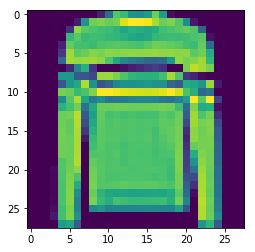

In [6]:
# Show one of the images from the training dataset
img_index=5
plt.imshow(X_train[img_index])

In [7]:
print(y_test[0:10])

[9 2 1 1 6 1 4 6 5 7]


convert each 28 x 28 image of the train and test set into a matrix of size 28 x 28 x 1 which is fed into the network.

In [8]:
X_train = X_train.reshape(-1, 28,28, 1)
X_test = X_test.reshape(-1, 28,28, 1)
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

he data right now is in an int8 format, so before you feed it into the network you need to convert its type to float32

In [9]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [10]:
# Change the labels from categorical to one-hot encoding
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)
#Display the change for category label using one-hot encoding
print('Original label:', y_train[0])
print('After conversion to one-hot:', y_train_one_hot[0])

Original label: 9
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [11]:
print(y_train.shape)
print('First 5 examples now are: ', y_train[0:5])

(60000,)
First 5 examples now are:  [9 0 0 3 0]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

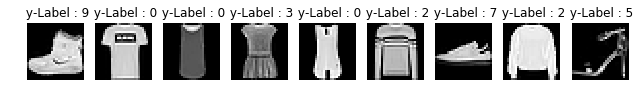

In [12]:
plt.figure(figsize = (12,2))
for i in range(1,10):
    plt.subplot(1,10,i)    
    plt.imshow(X_train[i-1].reshape(28,28), cmap='gray', interpolation='nearest')
    plt.axis('off')
    plt.title(" y-Label : {}".format(y_train[i-1]))
    # plt.tight_layout()

In [13]:
print("Number of train data - " + str(len(X_train)))
print("Number of test data - " + str(len(X_test)))

Number of train data - 60000
Number of test data - 10000


In [14]:
# Find the unique numbers from the train labels
classes = np.unique(y_train)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  [0 1 2 3 4 5 6 7 8 9]


### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [15]:
# Split the data set into training and testing
X_traini, X_testi, y_traini, y_testi = train_test_split(X_train, y_train_one_hot, test_size=0.2, random_state=7)

In [16]:
X_traini.shape,X_testi.shape,y_traini.shape,y_testi.shape

((48000, 28, 28, 1), (12000, 28, 28, 1), (48000, 10), (12000, 10))

In [17]:
model = Sequential()
model.add(Conv2D(1, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.sgd(),metrics=['accuracy'])

Instructions for updating:
Colocations handled automatically by placer.


In [18]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 28, 28, 1)         10        
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 1)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 196)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1970      
Total params: 1,980
Trainable params: 1,980
Non-trainable params: 0
_________________________________________________________________


### Execute the model using model.fit()

In [19]:
# Fit the model
model.fit(X_traini, y_traini, epochs=5, batch_size=5)

Instructions for updating:
Use tf.cast instead.
Epoch 1/5
48000/48000 [==============================] - 40s 837us/step - loss: 14.5054 - acc: 0.1000
Epoch 2/5
48000/48000 [==============================] - 39s 812us/step - loss: 14.5059 - acc: 0.1000
Epoch 3/5
48000/48000 [==============================] - 41s 856us/step - loss: 14.5059 - acc: 0.1000
Epoch 4/5
48000/48000 [==============================] - 38s 793us/step - loss: 14.5059 - acc: 0.1000
Epoch 5/5
48000/48000 [==============================] - 37s 772us/step - loss: 14.5059 - acc: 0.1000


In [20]:
test_e = model.evaluate(X_testi,y_testi, verbose=0)

In [21]:
print('Test loss: ', test_e[0])
print('Test accuracy:  % 5.2f' % (test_e[1]*100) ,'%' )

Test loss:  14.504942512512207
Test accuracy:   10.01 %


In [22]:
# Fit the model
model.fit(X_train, y_train_one_hot, epochs=5, batch_size=5)

Epoch 1/5
60000/60000 [==============================] - 52s 865us/step - loss: 14.5057 - acc: 0.1000
Epoch 2/5
60000/60000 [==============================] - 52s 874us/step - loss: 14.5057 - acc: 0.1000
Epoch 3/5
60000/60000 [==============================] - 44s 738us/step - loss: 14.5057 - acc: 0.1000
Epoch 4/5
60000/60000 [==============================] - 43s 710us/step - loss: 14.5057 - acc: 0.1000
Epoch 5/5
60000/60000 [==============================] - 51s 852us/step - loss: 14.5057 - acc: 0.1000


### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [23]:
X_train = X_train / 255.
X_test = X_test / 255.

### Execute the model

In [24]:
# Fit the model
model.fit(X_train, y_train_one_hot, epochs=5, batch_size=5)

Epoch 1/5
60000/60000 [==============================] - 51s 852us/step - loss: 2.0816 - acc: 0.7324
Epoch 2/5
60000/60000 [==============================] - 45s 751us/step - loss: 0.4693 - acc: 0.8351
Epoch 3/5
60000/60000 [==============================] - 52s 873us/step - loss: 0.4507 - acc: 0.8420
Epoch 4/5
60000/60000 [==============================] - 50s 830us/step - loss: 0.4416 - acc: 0.8454
Epoch 5/5
60000/60000 [==============================] - 50s 837us/step - loss: 0.4380 - acc: 0.8467


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [25]:
model_sgdo1 = Sequential()
model_sgdo1.add(Conv2D(1, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model_sgdo1.add(MaxPooling2D((2, 2)))
model_sgdo1.add(Flatten())
model_sgdo1.add(Dense(10, activation='softmax'))
opt = SGD(lr=0.001, momentum=0.9)
model_sgdo1.compile(loss=keras.losses.categorical_crossentropy, optimizer=opt,metrics=['accuracy'])

In [26]:
# Fit the model
model_sgdo1.fit(X_train, y_train_one_hot, epochs=30, batch_size=5)

Epoch 1/30
60000/60000 [==============================] - 48s 805us/step - loss: 0.5721 - acc: 0.7970
Epoch 2/30
60000/60000 [==============================] - 38s 627us/step - loss: 0.4643 - acc: 0.8374
Epoch 3/30
60000/60000 [==============================] - 46s 770us/step - loss: 0.4494 - acc: 0.8433
Epoch 4/30
60000/60000 [==============================] - 51s 856us/step - loss: 0.4419 - acc: 0.8455
Epoch 5/30
60000/60000 [==============================] - 48s 802us/step - loss: 0.4368 - acc: 0.8461
Epoch 6/30
60000/60000 [==============================] - 51s 854us/step - loss: 0.4331 - acc: 0.8485
Epoch 7/30
60000/60000 [==============================] - 49s 816us/step - loss: 0.4301 - acc: 0.8510
Epoch 8/30
60000/60000 [==============================] - 51s 843us/step - loss: 0.4279 - acc: 0.8491
Epoch 9/30
60000/60000 [==============================] - 47s 789us/step - loss: 0.4248 - acc: 0.8523
Epoch 10/30
60000/60000 [==============================] - 67s 1ms/step - loss: 0.

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [29]:
model_sgdo2 = Sequential()
model_sgdo2.add(Conv2D(100, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model_sgdo2.add(Dense(100, activation='softmax'))
model_sgdo2.add(MaxPooling2D((2, 2)))
model_sgdo2.add(Flatten())
model_sgdo2.add(Dense(10, activation='softmax'))
opt = SGD(lr=0.03, momentum=0.9)
model_sgdo2.compile(loss=keras.losses.categorical_crossentropy, optimizer=opt,metrics=['accuracy'])

In [28]:
# Fit the model
model_sgdo2.fit(X_train, y_train_one_hot, epochs=5, batch_size=5)

Instructions for updating:
Deprecated in favor of operator or tf.math.divide.
Epoch 1/5
60000/60000 [==============================] - 785s 13ms/step - loss: 0.5710 - acc: 0.8041
Epoch 2/5
60000/60000 [==============================] - 718s 12ms/step - loss: 0.3927 - acc: 0.8639
Epoch 3/5
60000/60000 [==============================] - 693s 12ms/step - loss: 0.3541 - acc: 0.87636s - lo
Epoch 4/5
60000/60000 [==============================] - 698s 12ms/step - loss: 0.3246 - acc: 0.88765s - loss: 0. - ETA: 4s 
Epoch 5/5
60000/60000 [==============================] - 2419s 40ms/step - loss: 0.3036 - acc: 0.8933


## Review model

In [39]:
test_eval = model_sgdo2.evaluate(X_test, y_test_one_hot, verbose=0)

In [47]:
print('Test loss: ', test_eval[0])
print('Test accuracy:  % 5.2f' % (test_eval[1]*100) ,'%' )

Test loss: 0.3597107204437256
Test accuracy:   88.26 %


### Run the model

In [51]:
model_ad = Sequential()
model_ad.add(Conv2D(32, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model_ad.add(Dense(100, activation='softmax'))
model_ad.add(MaxPooling2D((2, 2)))
model_ad.add(Flatten())
model_ad.add(Dense(10, activation='softmax'))
model_ad.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])

In [52]:
# Fit the model
model_ad.fit(X_train, y_train_one_hot, epochs=1, batch_size=5)

Epoch 1/1
60000/60000 [==============================] - 373s 6ms/step - loss: 0.4422 - acc: 0.8401


In [53]:
model_ad1 = Sequential()
model_ad1.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model_ad1.add(MaxPooling2D((2, 2)))
model_ad1.add(Flatten())
model_ad1.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model_ad1.add(Dense(10, activation='softmax'))
# compile model
opt = SGD(lr=0.01, momentum=0.9)
model_ad1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [57]:
# Fit the model
model_ad1.fit(X_train, y_train_one_hot, epochs=50, batch_size=256)

Epoch 1/50
60000/60000 [==============================] - 19s 311us/step - loss: 0.1857 - acc: 0.9309
Epoch 2/50
60000/60000 [==============================] - 22s 368us/step - loss: 0.1813 - acc: 0.9330
Epoch 3/50
60000/60000 [==============================] - 23s 376us/step - loss: 0.1776 - acc: 0.9346
Epoch 4/50
60000/60000 [==============================] - 23s 391us/step - loss: 0.1739 - acc: 0.9364
Epoch 5/50
60000/60000 [==============================] - 23s 383us/step - loss: 0.1708 - acc: 0.9367
Epoch 6/50
60000/60000 [==============================] - 22s 372us/step - loss: 0.1679 - acc: 0.9386
Epoch 7/50
60000/60000 [==============================] - 23s 376us/step - loss: 0.1650 - acc: 0.9400
Epoch 8/50
60000/60000 [==============================] - 23s 390us/step - loss: 0.1616 - acc: 0.9407
Epoch 9/50
60000/60000 [==============================] - 25s 411us/step - loss: 0.1587 - acc: 0.9422
Epoch 10/50
60000/60000 [==============================] - 22s 374us/step - loss: 

In [30]:
model_ad2 = Sequential()
model_ad2.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model_ad2.add(MaxPooling2D((2, 2)))
model_ad2.add(Flatten())
model_ad2.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model_ad2.add(Dense(10, activation='softmax'))
# compile model
opt = SGD(lr=0.05, momentum=0.9)
model_ad2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
# Fit the model
model_ad2.fit(X_train, y_train_one_hot, epochs=30, batch_size=256)

Epoch 1/30
60000/60000 [==============================] - 31s 521us/step - loss: 0.5334 - acc: 0.8177
Epoch 2/30
60000/60000 [==============================] - 28s 468us/step - loss: 0.3002 - acc: 0.8921
Epoch 3/30
60000/60000 [==============================] - 27s 455us/step - loss: 0.2588 - acc: 0.9061
Epoch 4/30
60000/60000 [==============================] - 29s 475us/step - loss: 0.2382 - acc: 0.9124
Epoch 5/30
60000/60000 [==============================] - 29s 479us/step - loss: 0.2167 - acc: 0.9200
Epoch 6/30
60000/60000 [==============================] - 29s 478us/step - loss: 0.1974 - acc: 0.9271
Epoch 7/30
60000/60000 [==============================] - 31s 510us/step - loss: 0.1859 - acc: 0.9318
Epoch 8/30
60000/60000 [==============================] - 29s 488us/step - loss: 0.1729 - acc: 0.9373
Epoch 9/30
60000/60000 [==============================] - 27s 452us/step - loss: 0.1573 - acc: 0.9426
Epoch 10/30
60000/60000 [==============================] - 27s 448us/step - loss: 

In [32]:
test_eval1 = model_ad2.evaluate(X_test, y_test_one_hot, verbose=0)

In [33]:
print('Test loss: ', test_eval1[0])
print('Test accuracy:  % 5.2f' % (test_eval1[1]*100) ,'%' )

Test loss:  0.425646279123053
Test accuracy:   90.69 %


In [34]:
model_ad3 = Sequential()
model_ad3.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model_ad3.add(MaxPooling2D((2, 2)))
model_ad3.add(Flatten())
model_ad3.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model_ad3.add(Dense(10, activation='softmax'))


In [ ]:
# compile model
opt = SGD(lr=0.03, momentum=0.9)
model_ad3.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [35]:
# Fit the model
model_ad3.fit(X_train, y_train_one_hot, epochs=50, batch_size=512)

Epoch 1/50
60000/60000 [==============================] - 18s 300us/step - loss: 0.5926 - acc: 0.7933
Epoch 2/50
60000/60000 [==============================] - 19s 322us/step - loss: 0.3444 - acc: 0.87892s - loss: 0.346
Epoch 3/50
60000/60000 [==============================] - 20s 340us/step - loss: 0.3065 - acc: 0.8914
Epoch 4/50
60000/60000 [==============================] - 21s 343us/step - loss: 0.2796 - acc: 0.9005
Epoch 5/50
60000/60000 [==============================] - 20s 338us/step - loss: 0.2570 - acc: 0.9082
Epoch 6/50
60000/60000 [==============================] - 21s 350us/step - loss: 0.2376 - acc: 0.9157
Epoch 7/50
60000/60000 [==============================] - 21s 349us/step - loss: 0.2253 - acc: 0.9190
Epoch 8/50
60000/60000 [==============================] - 21s 350us/step - loss: 0.2118 - acc: 0.92463s - loss: 0.2123 - ETA: 1s - loss: 0.2111 - acc:
Epoch 9/50
60000/60000 [==============================] - 21s 349us/step - loss: 0.2016 - acc: 0.9289
Epoch 10/50
60000

In [37]:
test_eval3 = model_ad3.evaluate(X_test, y_test_one_hot, verbose=0)
print('Test loss: ', test_eval3[0])
print('Test accuracy:  % 5.2f' % (test_eval3[1]*100) ,'%' )

Test loss:  0.4192113423787057
Test accuracy:   91.13 %
